In [1]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from utils import *
import seaborn as sns
import matplotlib.colors as mcolors


In [2]:
config = yaml.safe_load(open('/Users/ursic/PhD/Projects/1_DataAnalysis_zebrafish/beads_in_zebrafish/magnetic_tweezers_SD/config.yml'))

filepath_measurements_info = config['filepath_measurements_info']
dir_plots = os.path.join(config['dir_parent'], '3_plots')  # Folder for saving plots
dir_analysis = os.path.join(config['dir_parent'], '2_analysis')  # Folder for saving analysis results
recalculate = config['recalculate']  # Whether to recalculate measurements if they already exist
pix_size = config['pix_size'] 
dt = config['dt']  # Time step in seconds

force_ranges = config['force_ranges']  # Force ranges for averaging curves

subtract_backgroung = config['subtract_background']  # Whether to subtract background from displacement

creep_only = False
if config['fit_type'] == 'creep jeff':
    creep_only = True  # If the fit type is 'creep jeff', we only plot creep curves
    
creep_only_label = '_only_creep' if creep_only else ''

displacement_column = 'CORRECTED DISPLACEMENT [um]' if subtract_backgroung else 'DISPLACEMENT [um]'  # Use the original displacement, not corrected
subtr_bck_label = 'subtr_bck' if subtract_backgroung else 'no_subtr_bck'

In [3]:
# Get the first two colors from the default Seaborn color palette
base_colors = sns.color_palette("tab10", 2)  # Blue and Orange

# Create the darker versions
darker_colors = sns.color_palette("dark", 2)  # Blue and Orange

# Combine into a single palette
custom_palette = [base_colors[0], darker_colors[0], base_colors[1], darker_colors[1]]

In [4]:
custom_dict = {'y': 0, 'taxol': 1, 'n': 2, 'noco': 3} 
pairs = [('y', 'taxol'), ('n', 'noco'), ('taxol', 'noco'), ('y', 'n')]
t_on, t_off = 10, 30

df_data_control_all = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properties_no_subtr_bck.csv')
df_data_perturb_all = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properties_no_subtr_bck.csv')

# df_data_all_filtered = pd.concat([filter_data_params(df_data_control_all), filter_data_params(df_data_perturb_all)]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))
df_data_all_filtered = pd.concat([df_data_control_all, df_data_perturb_all]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_data_control_avg_curves = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_parameters_curve_averaged_force_range20-60pN_no_subtr_bck.csv')
df_data_perturb_avg_curves = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_parameters_curve_averaged_force_range20-60pN_no_subtr_bck.csv')

df_data_avg_curves = pd.concat([df_data_control_avg_curves, df_data_perturb_avg_curves]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_stats_control = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properies_avg_curves_stats_no_subtr_bck.csv')
df_stats_perturbed = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properies_avg_curves_stats_no_subtr_bck.csv')

df_stats = pd.concat([df_stats_control, df_stats_perturbed]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))


In [5]:
df_data_avg_curves.head()

,EMBRYO,MT_STATUS,AVG_FORCE,MAGNET_STATUS,COUNT,k,eta_1,eta_2,k_err,eta_1_err,eta_2_err,t_1,R_SQUARED,rising_dif,relaxing_dif,rising_dif_norm,relative_dif,tau_r,a,elastic_viscous_ratio
0,20240621s01p01,y,40.914211,NaN,131,24.931339,61.252732,318.532029,0.751738,1.957825,8.974181,4.5,0.982001,1.975780,1.477294,0.048291,0.747702,1.228428,0.704534,2.384480
3,20240614s02p02,y,44.176762,NaN,14,22.611039,64.604820,250.606084,0.744275,1.911531,6.280872,4.5,0.982677,2.250629,1.483305,0.050946,0.659063,1.428612,0.661372,1.953091
6,20240523s02p01,y,33.114355,NaN,43,20.168007,39.201482,109.179984,0.451568,1.160663,1.057298,4.5,0.988826,2.754699,1.416612,0.083187,0.514253,0.971873,0.520200,1.084203
4,20240703s03p01,y,31.431040,NaN,94,10.272429,27.284024,180.010614,0.371831,0.964023,8.089383,4.5,0.977027,3.428239,2.837507,0.109072,0.827687,1.328022,0.760688,3.178648
13,20240705s02p01,y,28.680260,NaN,21,12.930712,35.405347,160.740614,0.555134,1.434548,6.000744,4.5,0.968825,2.587776,1.927989,0.090228,0.745037,1.369041,0.690252,2.228435


In [6]:
params = ['k', 'eta_1', 'eta_2', 'elastic_viscous_ratio', 'rising_dif', 'rising_dif_norm', 'relative_dif', 'a', 'tau_r']

labels = ['$\\kappa$ (pN/$\\mathrm{\\mu m}$)', '$\\gamma_1$ (pN s/$\\mathrm{\\mu m}$)', '$\\gamma_2$ (pN s/$\\mathrm{\\mu m}$)', 'Ratio between elastic and viscous deformation', 'Displacement ($\\mathrm{\\mu m}$)', 'Displacement / Force ($\\mathrm{\\mu m}$/ pN)', 'a = Relaxation / Displacement ', 'a', '$\\tau_R$']

mapping = {'noco': 'Nocodazole', 'taxol': 'Taxol', 'y': 'Interphase', 'n': 'M-Phase'}

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(-0.33322828311357355), np.float64(0.7691451845923376), np.float64(2.112860477358359))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(4.080494981615149), np.float64(0.0009844637435089758), np.float64(14.999803226789487))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(0.6981691360717288), np.float64(0.5564044827510355), np.float64(2.0296564262698285))
(array([2.50318471, 0.26751592, 0.82165605,

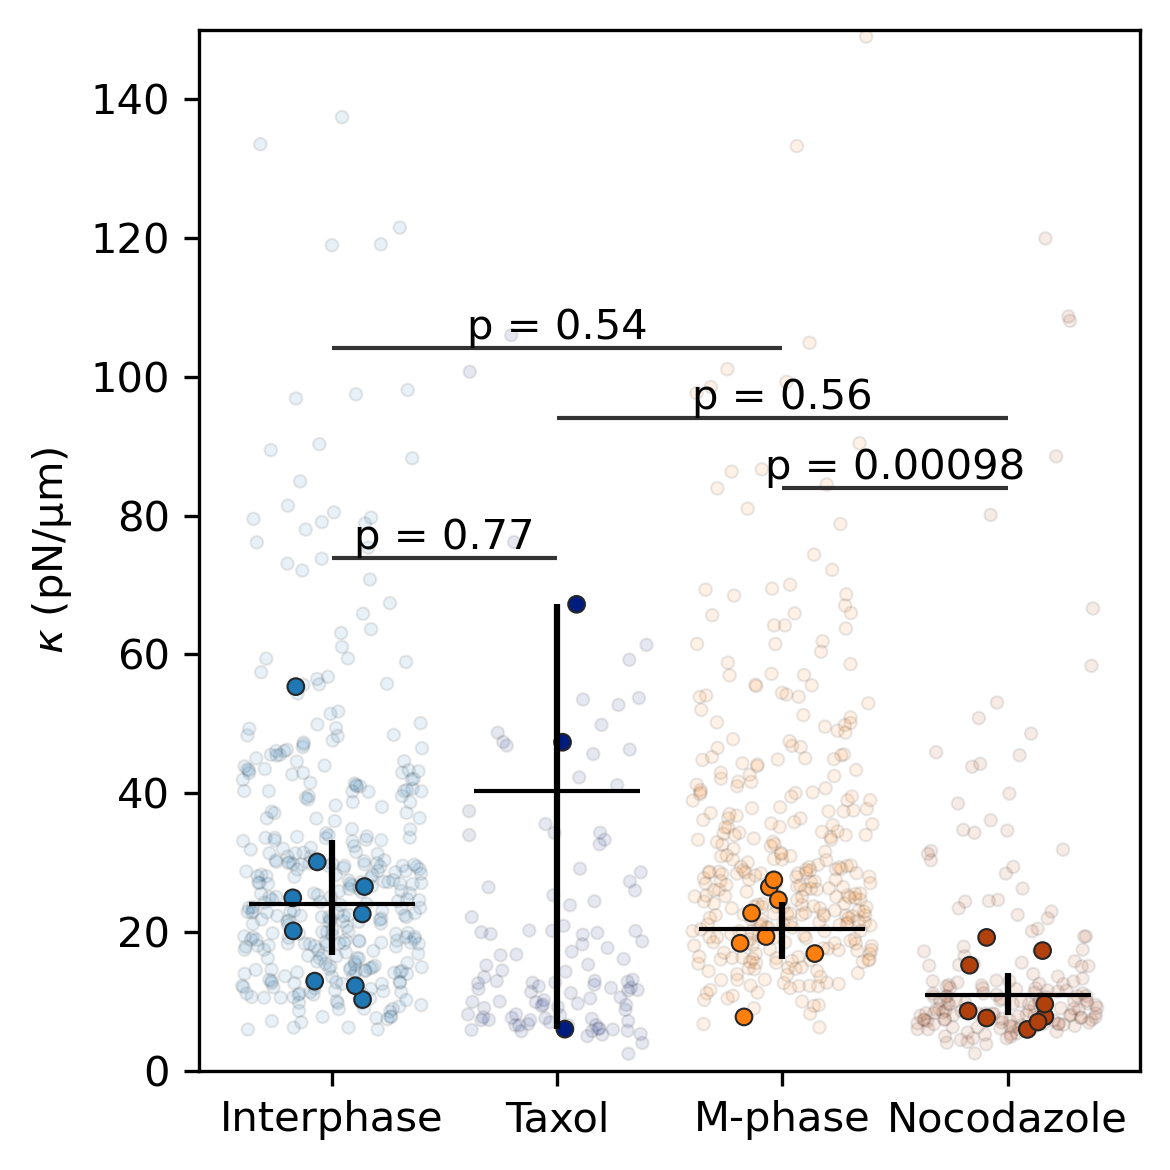

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(0.1333471957140654), np.float64(0.9048472993840707), np.float64(2.2635670009718405))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(1.7985499860095921), np.float64(0.09822847663735004), np.float64(11.560280048947147))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(1.2111518989868604), np.float64(0.34672653218590566), np.float64(2.05456181574773))
(array([2.50318471, 0.26751592, 0.82165605, 1.

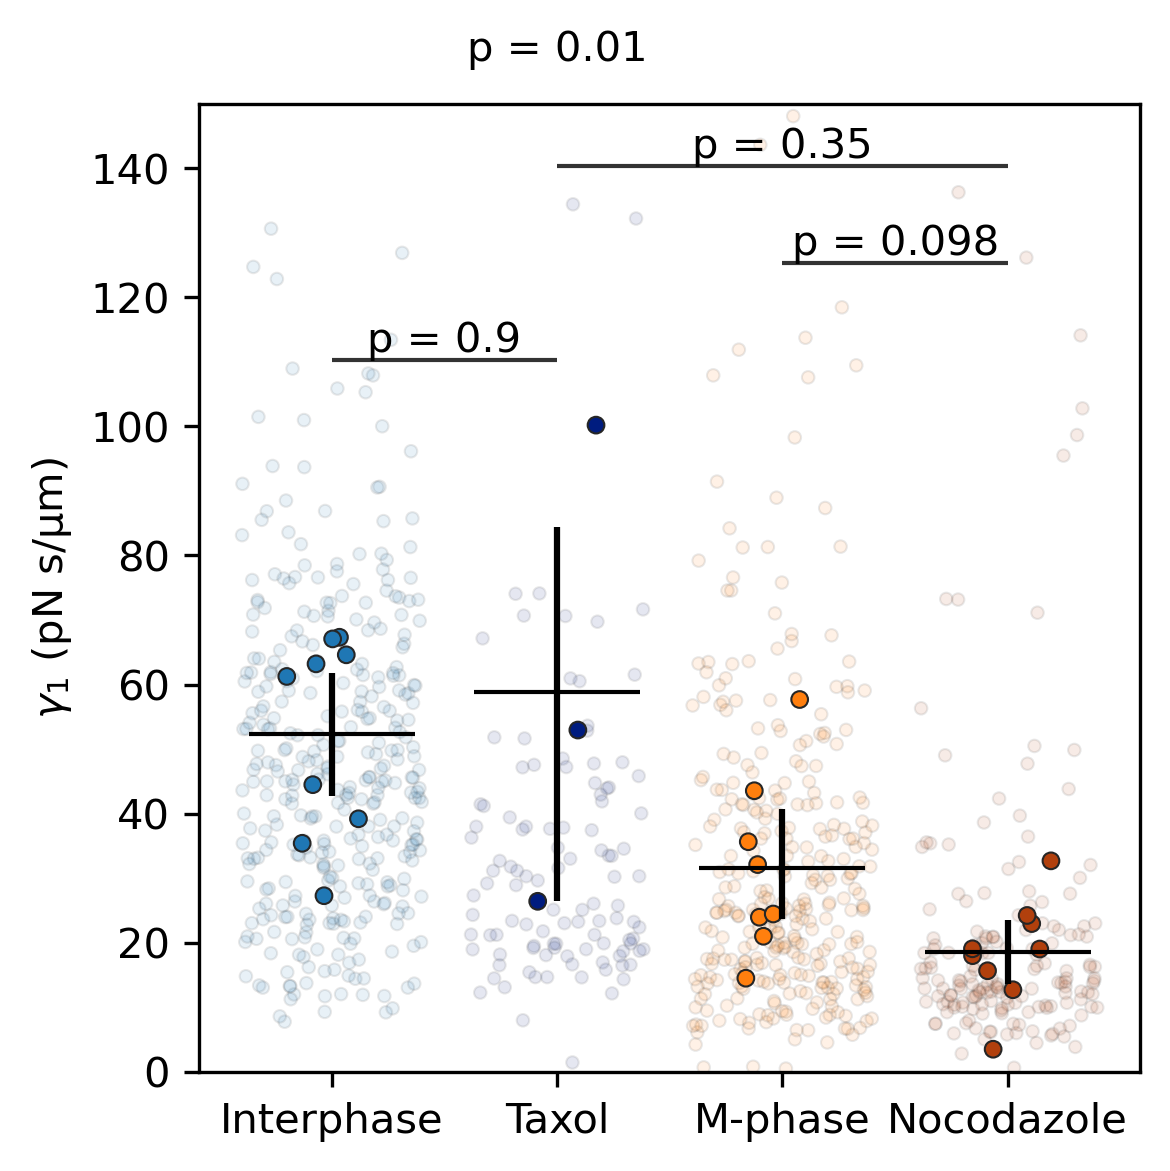

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(2.1544967142106235), np.float64(0.058143218091151916), np.float64(9.46378426145787))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(1.2733491380380226), np.float64(0.22671246068642098), np.float64(12.152378953293171))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(5.150507273633468), np.float64(0.03200043264729962), np.float64(2.1060732856534656))
(array([2.50318471, 0.26751592, 0.82165605, 1

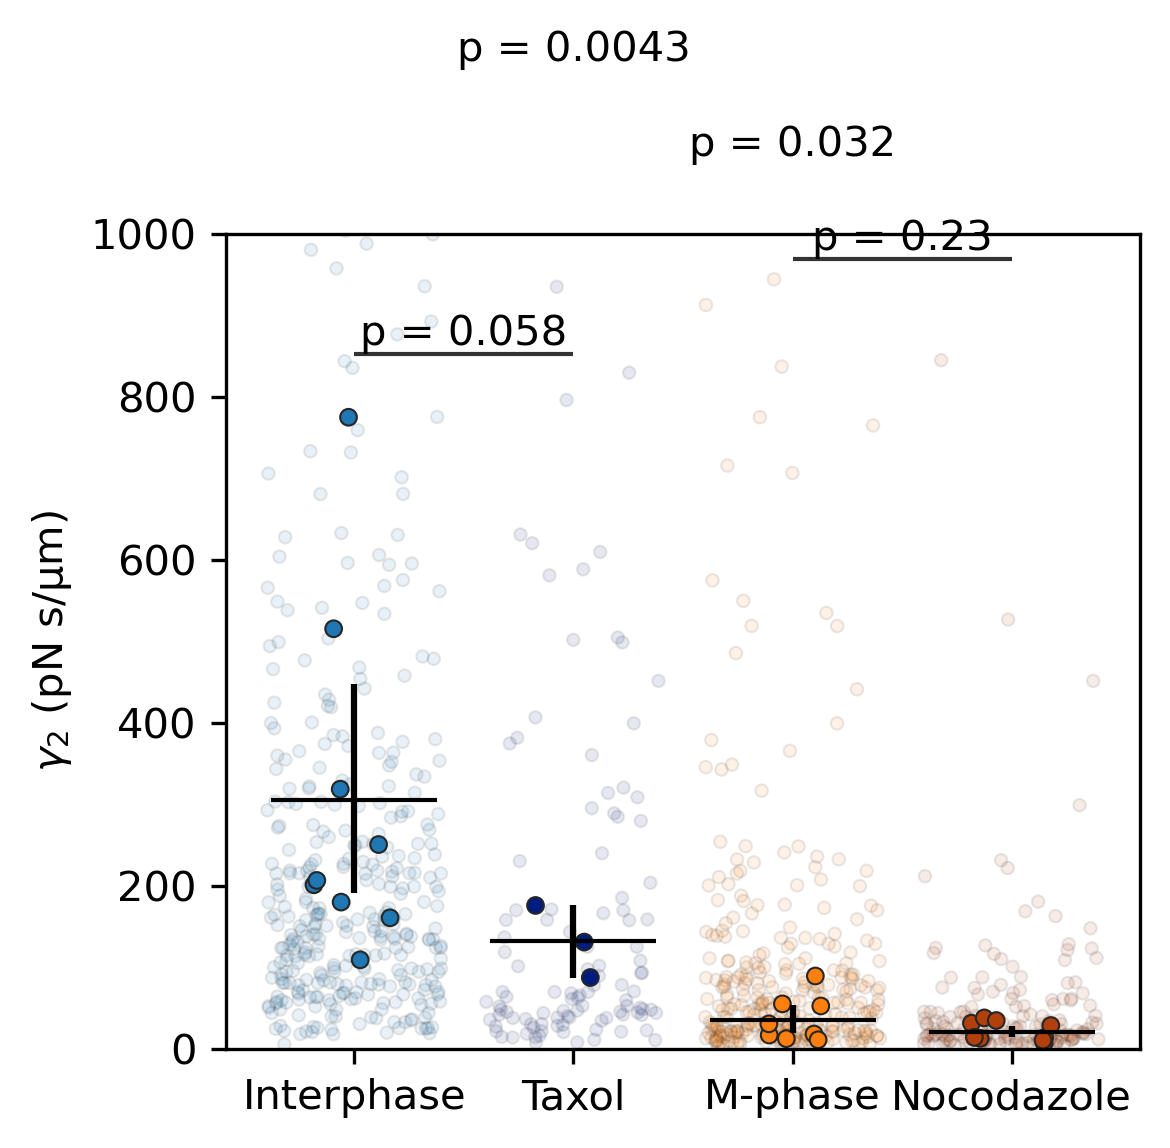

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(0.11139063687293722), np.float64(0.9199134704835211), np.float64(2.409142303737877))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-1.0561390983280143), np.float64(0.3094914941659979), np.float64(13.461185439599815))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(1.7568845104977264), np.float64(0.2203680251449849), np.float64(2.010411814715834))
(array([2.50318471, 0.26751592, 0.82165605, 1.

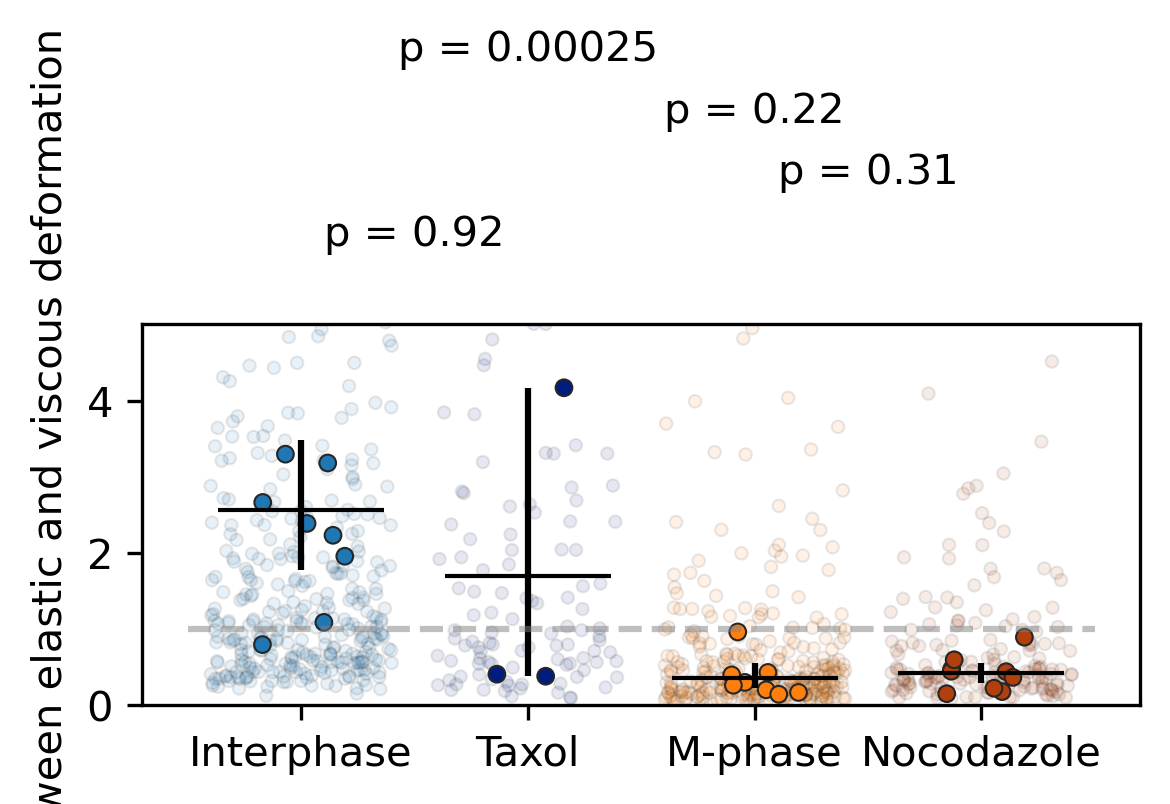

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(-0.046758039891096684), np.float64(0.9655819614006371), np.float64(3.070237974465751))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-0.3218049376167501), np.float64(0.7523746653372931), np.float64(13.941917933015665))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(-3.426335785930949), np.float64(0.007975213014979415), np.float64(8.674367888864351))
(array([2.50318471, 0.26751592, 0.82165605

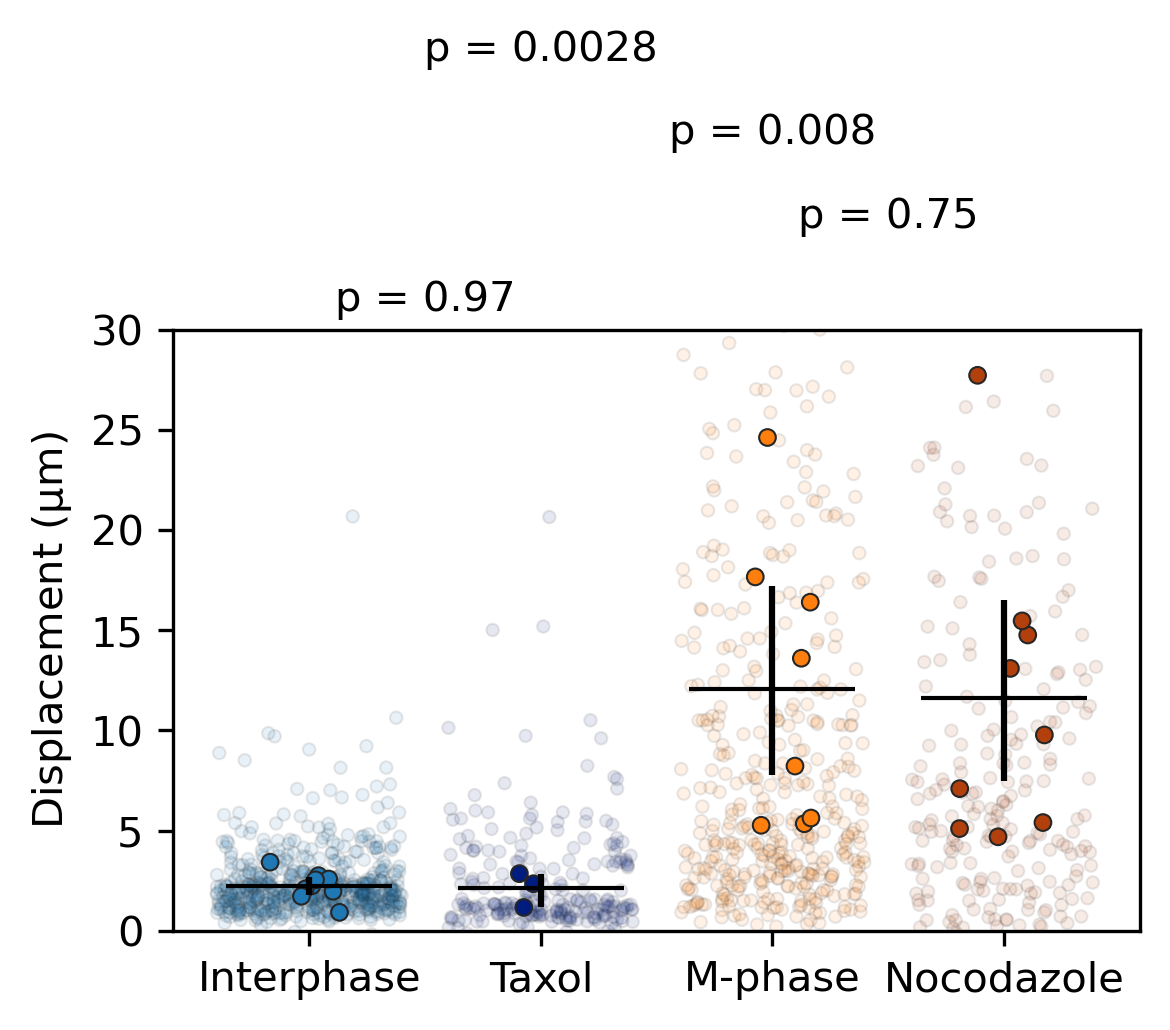

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(-1.3511295112942296), np.float64(0.28214709775365804), np.float64(2.6011794692504377))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-1.5656474329289976), np.float64(0.14304648484221688), np.float64(12.172355164937905))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(-3.251537157188012), np.float64(0.009067146154801918), np.float64(9.681480819059981))
(array([2.50318471, 0.26751592, 0.8216560

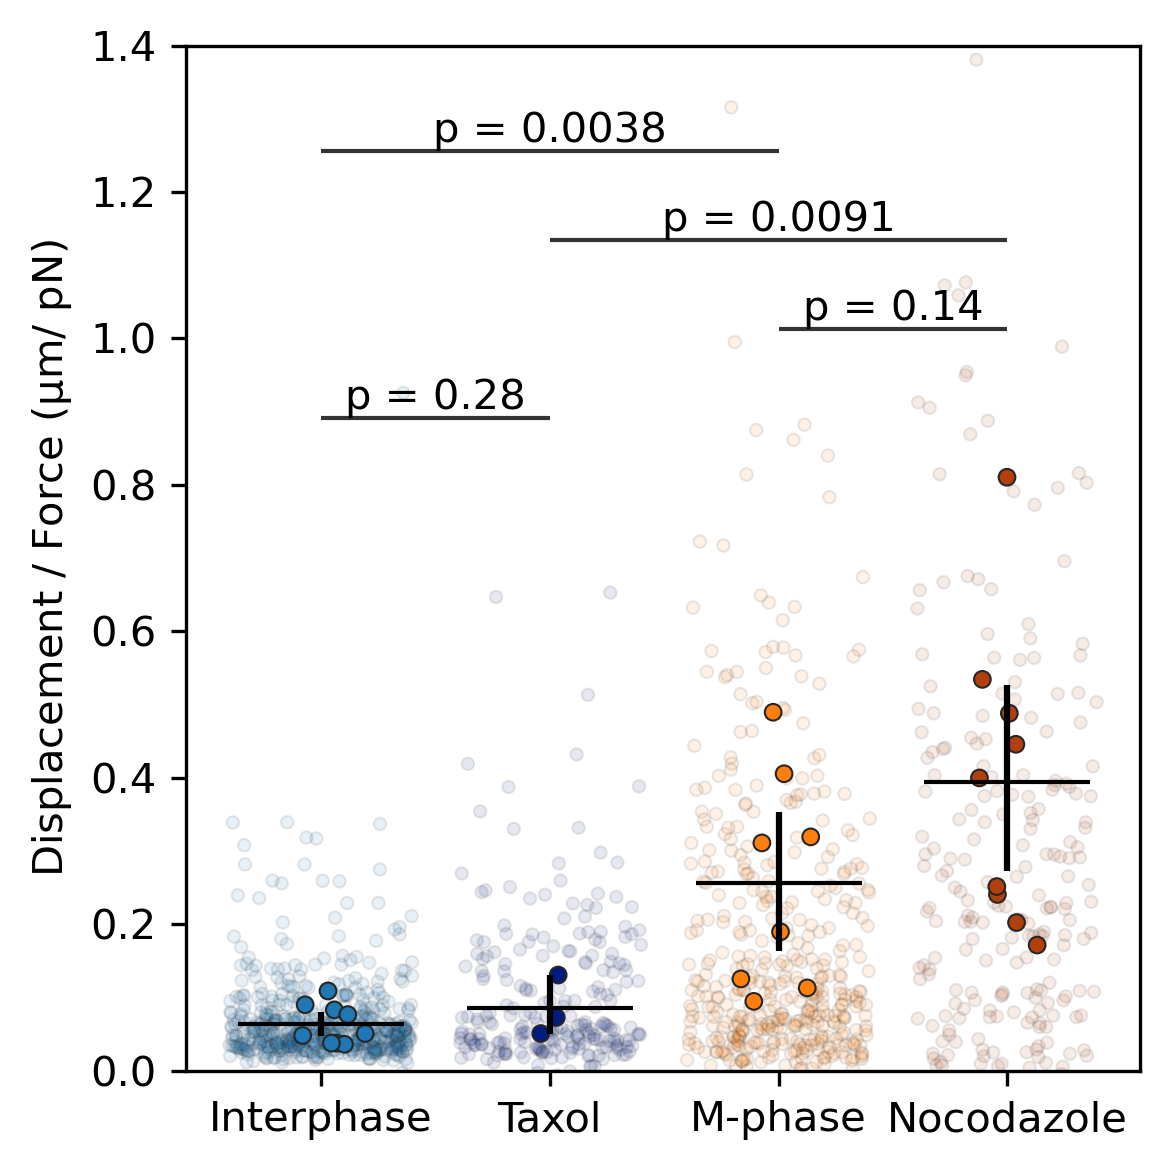

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(0.7869786267177877), np.float64(0.5089220167787447), np.float64(2.1432756091323633))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-0.5689696311574541), np.float64(0.5779603553944479), np.float64(14.711683268061638))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(1.4511903558664798), np.float64(0.2792681767879664), np.float64(2.080509572100383))
(array([2.50318471, 0.26751592, 0.82165605, 1.

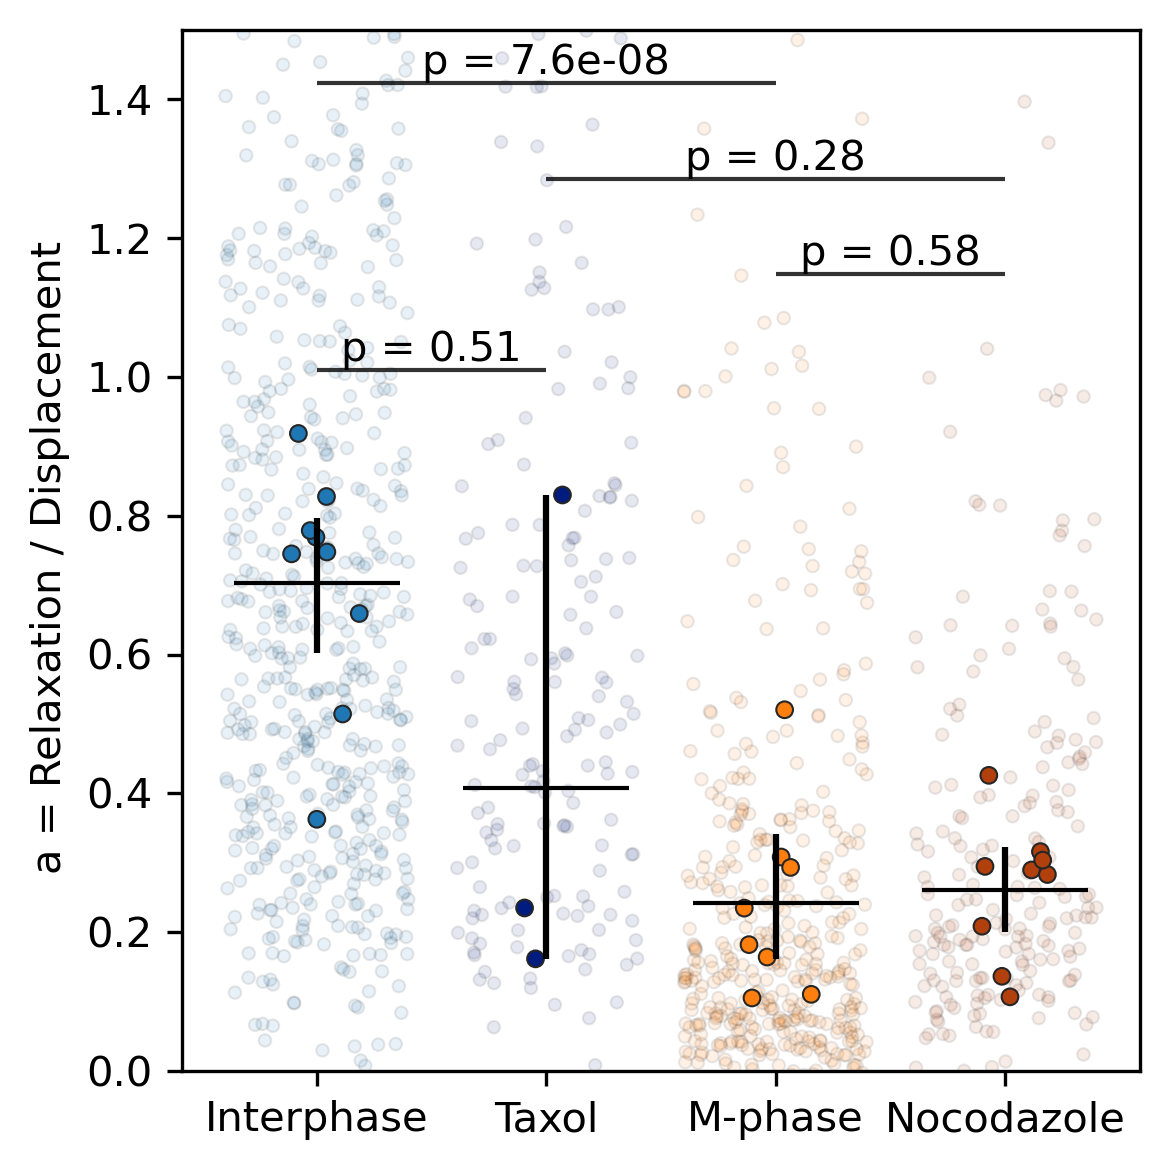

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(0.6230038707329175), np.float64(0.5936117268568928), np.float64(2.122807988470899))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-0.9618166274602906), np.float64(0.35278969396050897), np.float64(13.718299191773065))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(1.7849686697432305), np.float64(0.20817681439284114), np.float64(2.1348233394963074))
(array([2.50318471, 0.26751592, 0.82165605, 

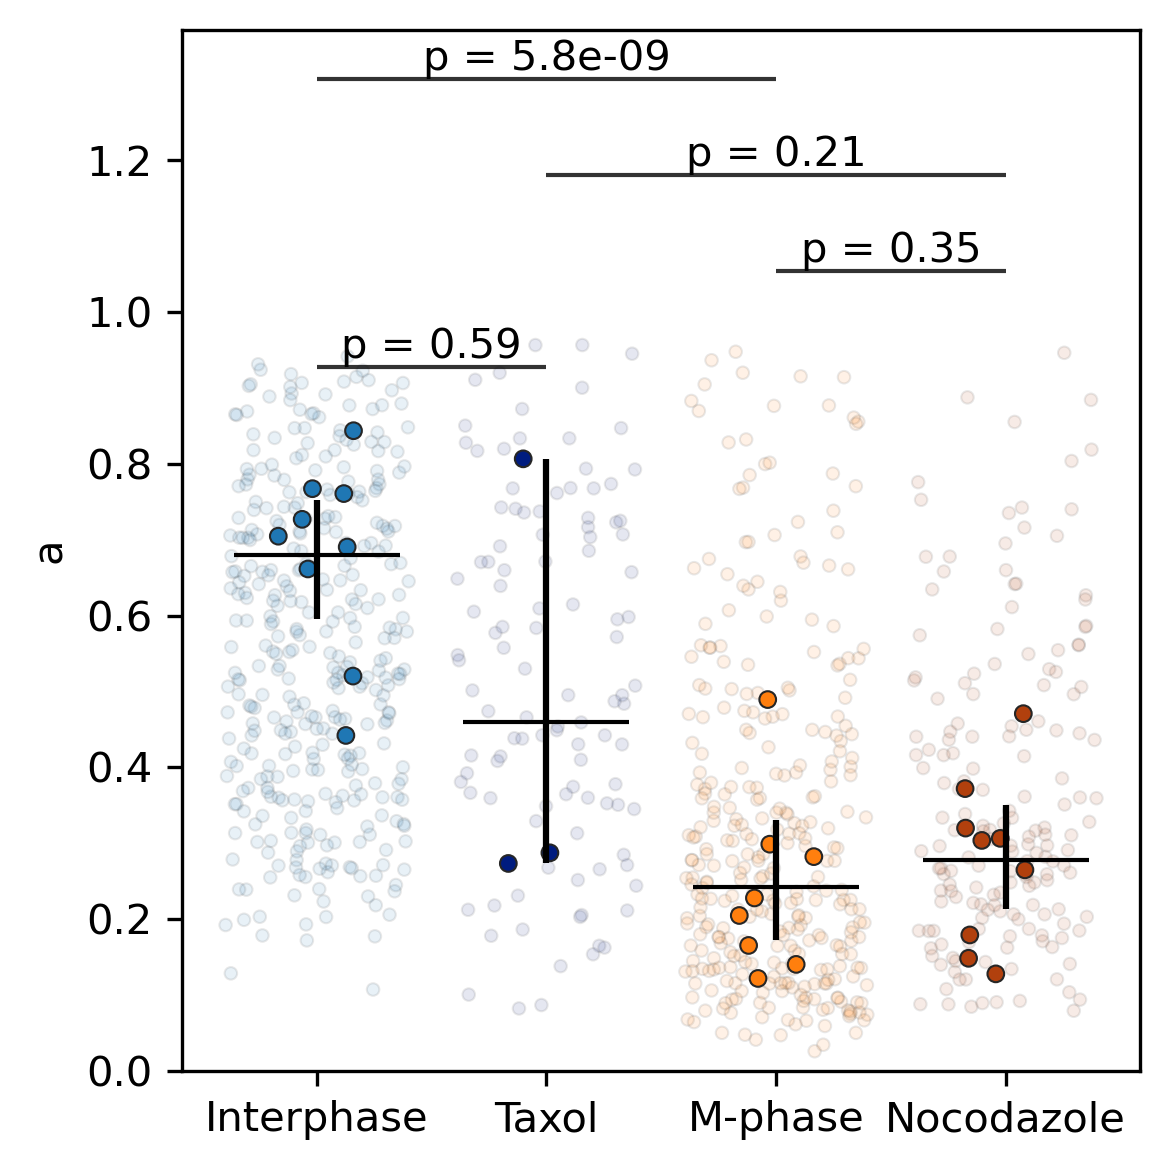

(array([2.50318471, 0.26751592, 0.82165605, 1.79617834, 0.40127389,
       0.21019108, 1.37579618, 0.47770701, 1.14649682]), array([0.52173913, 0.65217391, 1.82608696]))
P-value for ('y', 'taxol'): (np.float64(-0.5335683722333958), np.float64(0.6443429637800565), np.float64(2.119120479416485))
(array([0.10526316, 1.96491228, 1.61403509, 0.84210526, 0.10526316,
       0.21052632, 2.98245614, 0.1754386 ]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('n', 'noco'): (np.float64(-1.391901272902578), np.float64(0.18611091951252054), np.float64(13.716909900263396))
(array([0.52173913, 0.65217391, 1.82608696]), array([1.34693878, 2.81632653, 0.67346939, 0.42857143, 0.36734694,
       1.53061224, 0.73469388, 0.6122449 , 0.48979592]))
P-value for ('taxol', 'noco'): (np.float64(1.3912869980659346), np.float64(0.2904355033557718), np.float64(2.153439460070299))
(array([2.50318471, 0.26751592, 0.82165605, 1.

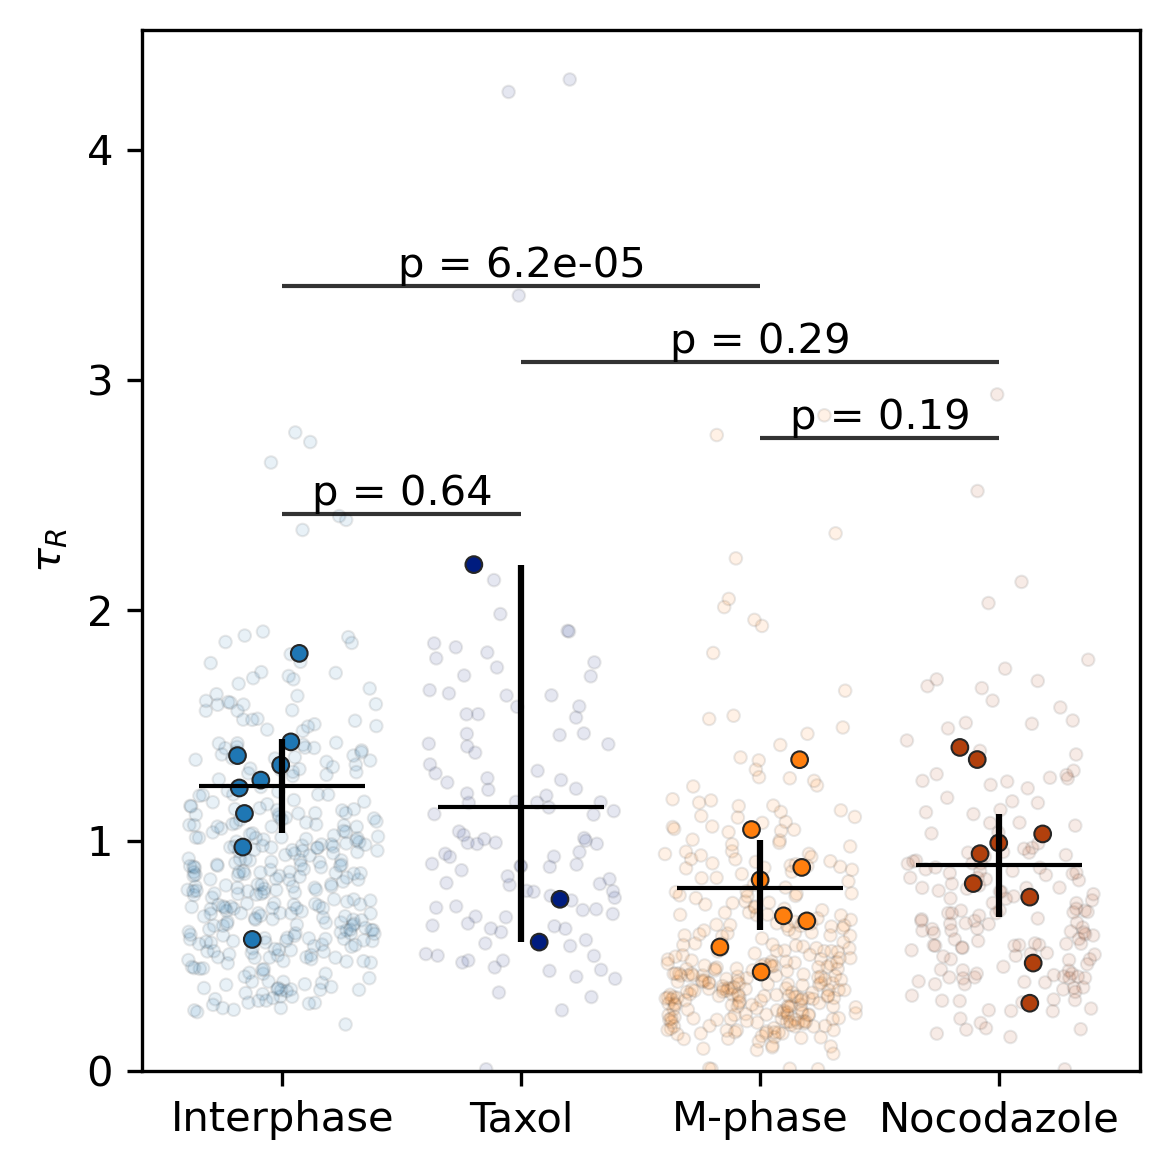

In [7]:
for (param, label) in zip(params, labels):
    df = df_data_all_filtered
    if param in ['k', 'eta_1', 'eta_2', 'elastic_viscous_ratio', 'a', 'tau_r']:
        df = filter_data_params(df_data_all_filtered)
    fig = plt.figure(figsize=(4, 4), dpi=300)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df, jitter=0.4, alpha=0.1, linewidth=0.5, legend=False, size=3, zorder=0, palette=custom_palette)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df_data_avg_curves, jitter=0.2, alpha=1, linewidth=0.5, legend=False, size=4, zorder=1, palette=custom_palette)

    plt.errorbar(df_stats.loc[df_stats['parameter']==param, 'MT_STATUS'], 
                df_stats.loc[df_stats['parameter']==param, 'weighted_average'], 
                yerr=np.array([df_stats.loc[df_stats['parameter']==param, 'y_err_low'].values, df_stats.loc[df_stats['parameter']==param, 'y_err_high'].values]), 
                marker = '_', markersize=40,  color='k', linestyle='', zorder=2)

    # plt.title(f'p = {p_value:.2g}')
    for (i, pair) in enumerate(pairs):
        weights = (df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values*len(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values)/np.sum       (df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values), 
        df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values*len(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values)/np.sum(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values))
        # weights = (None, None)
        print(weights)
        plot_p_value(param, pair, df_data_avg_curves, weights, custom_dict, height_factor=1.1 + i*0.15)

    plt.ylabel(label)
    plt.xlabel('')
    plt.ylim(bottom=0)
    plt.xticks(ticks=['y', 'taxol', 'n', 'noco'], labels=['Interphase', 'Taxol', 'M-phase', 'Nocodazole'])
    if param == 'k':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_1':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_2':
        plt.ylim(bottom=0, top=1000)
    elif param == 'rising_dif_norm':
        plt.ylim(0, 1.4)   
    elif param == 'elastic_viscous_ratio':
        plt.ylim(bottom=0, top=5)
        plt.hlines(1, -0.5, 3.5, color='gray', linestyle='--', alpha=0.5)
    elif param == 'rising_dif':
        plt.ylim(bottom=0, top=30)
    elif param == 'relative_dif':
        plt.ylim(bottom=0, top=1.5)

    # plt.ylim(0, 1000)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f'{dir_plots}/results/result_comparison_{param}_{subtr_bck_label}.svg', format='svg')
    plt.savefig(f'{dir_plots}/results/result_comparison_{param}_{subtr_bck_label}.pdf')
    plt.show()